In [14]:
import numpy as np
from dctkit.mesh import util
from dctkit.math.opt import optctrl
from dctkit.physics.elasticity import LinearElasticity
import dctkit as dt
import pygmsh
import jax.numpy as jnp
from functools import partial
import matplotlib.pyplot as plt

In [11]:
lc = 0.2
L = 1.
with pygmsh.geo.Geometry() as geom:
    p = geom.add_polygon([[0., 0.], [L, 0.], [L, L], [0., L]], mesh_size=lc)
    # create a default physical group for the boundary lines
    geom.add_physical(p.lines, label="boundary")
    geom.add_physical(p.lines[1], label="right")
    geom.add_physical(p.lines[3], label="left")
    mesh = geom.generate_mesh()

S = util.build_complex_from_mesh(mesh)
S.get_hodge_star()
S.get_flat_DPD_weights()
S.get_flat_DPP_weights()

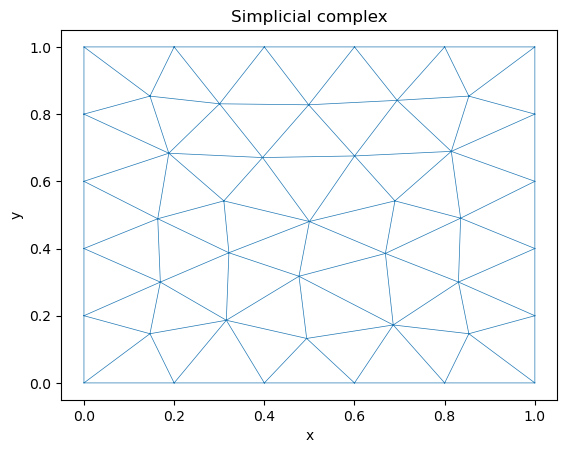

In [15]:
# mesh plot
plt.triplot(S.node_coords[:, 0], S.node_coords[:, 1], triangles=S.S[2],  linewidth=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simplicial complex")
plt.show()

In [12]:
ref_node_coords = S.node_coords

bnd_edges_idx = S.boundary_simplices[S.dim-1]
left_bnd_nodes_idx = util.get_nodes_for_physical_group(mesh, 1, "left")
right_bnd_nodes_idx = util.get_nodes_for_physical_group(mesh, 1, "right")
left_bnd_edges_idx = util.get_edges_for_physical_group(S, mesh, "left")
right_bnd_edges_idx = util.get_edges_for_physical_group(S, mesh, "right")

bot_left_corn_idx = left_bnd_nodes_idx.index(0)
bottom_left_corner = left_bnd_nodes_idx[bot_left_corn_idx]

In [16]:
mu_ = 1.
lambda_ = 10.
true_strain_xx = 0.5
true_strain_yy = -(lambda_/(2*mu_+lambda_))*true_strain_xx
true_curr_node_coords = S.node_coords.copy()
true_curr_node_coords[:, 0] *= 1 + true_strain_xx
true_curr_node_coords[:, 1] *= 1 + true_strain_yy
left_bnd_pos_components = [0]
right_bnd_pos_components = [0]

In [17]:
left_bnd_nodes_pos = ref_node_coords[left_bnd_nodes_idx,
                                         :][:, left_bnd_pos_components]
right_bnd_nodes_pos = true_curr_node_coords[right_bnd_nodes_idx,
                                            :][:, right_bnd_pos_components]
bottom_left_corner_pos = ref_node_coords[bottom_left_corner, :]

In [20]:
boundary_values = {"0": (left_bnd_nodes_idx + right_bnd_nodes_idx,
                         np.vstack((left_bnd_nodes_pos,
                                    right_bnd_nodes_pos)).flatten()),
                   ":": (bottom_left_corner, bottom_left_corner_pos)}

idx_free_edges = list(set(bnd_edges_idx) -
                      set(right_bnd_edges_idx) - set(left_bnd_edges_idx))
left_right_edges_idx = left_bnd_edges_idx+right_bnd_edges_idx
bnd_tractions_free_values = np.zeros((len(idx_free_edges), 2), dtype=dt.float_dtype)
bnd_tractions_left_right_values = np.zeros(
    (len(left_right_edges_idx)), dtype=dt.float_dtype)

boundary_tractions = {':': (idx_free_edges, bnd_tractions_free_values),
                      '1': (left_right_edges_idx, bnd_tractions_left_right_values)}

gamma = 100000.

In [28]:
def get_infinitesimal_strain(node_coords):
        """Compute the discrete strain tensor given the current node coordinates.

        Args:
            node_coords: current node coordinates.

        Returns:
            the discrete infinitesimal strain tensor.

        """
        # compute the deformation gradient
        num_faces = S.S[2].shape[0]
        F = S.get_deformation_gradient(node_coords)
        # epsilon = 1/2(F + F^T) - I
        epsilon = 1/2 * (F + jnp.transpose(F, axes=(0, 2, 1))) - \
            jnp.stack([jnp.identity(2)]*num_faces)
        return epsilon

def get_stress(strain):
    """Compute the discrete stress tensor from strains using the consistutive
    equation for isotropic linear elastic materials.

    Args:
        strain: discrete strain tensor.

    Returns:
        the discrete stress tensor.

    """
    num_faces = S.S[2].shape[0]
    tr_strain = jnp.trace(strain, axis1=1, axis2=2)
    # get the stress via the consistutive equation for isotropic linear
    # elastic materials
    stress = 2.*mu_*strain + lambda_*tr_strain[:, None, None] * \
        jnp.stack([jnp.identity(2)]*num_faces)
    return stress

def get_penalty_displacement_bc(node_coords, boundary_values, gamma):
        """Set displacement boundary conditions as a quadratic penalty term.

        Args:
            node_coords: node coordinates of the current configuration.
            boundary_values: a dictionary of tuples. Each key represent the type of
                coordinate to manipulate (x,y, or both), while each tuple consists of
                two np.arrays in which the first encodes the indices of boundary
                values, while the last encodes the boundary values themselves.
            gamma: penalty factor.

        Return:
            the penalty term.
        """
        penalty = 0.
        for key in boundary_values:
            idx, values = boundary_values[key]
            if key == ":":
                penalty += jnp.sum((node_coords[idx, :] - values)**2)
            else:
                penalty += jnp.sum((node_coords[idx, int(key)] - values)**2)
        return gamma*penalty

## Variational Formulation

In [24]:
def elasticity_energy(node_coords, f):
        """Compute the elasticity energy of isotropic linear elastic materials
        in 2D with no body force using DEC framework.

        Args:
            node_coords: primal vector valued 0-cochain of node coordinates
                of the current configuration.
            f: primal vector-valued 2-cochain of sources.

        Returns:
            the energy.
        """
        strain = get_infinitesimal_strain(node_coords=node_coords.coeffs)
        stress = get_stress(strain=strain)
        strain_cochain = C.CochainD0(S, strain)
        stress_cochain = C.CochainD0(S, stress)
        ref_node_coords = C.CochainP0(S, S.node_coords)
        displacement = C.sub(node_coords, ref_node_coords)
        elastic_energy = 0.5 * \
            C.inner(strain_cochain, stress_cochain) - \
            C.inner(displacement, f)
        return elastic_energy

In [25]:
def obj_linear_elasticity_energy(node_coords, f, gamma, boundary_values):
        """
        Objective function of the optimization problem associated to linear elasticity
        (energy formulation) with Dirichlet boundary conditions on a portion of the
        boundary.

        Args:
            node_coords: 1-dimensional array obtained after flattening the matrix with
                node coordinates arranged row-wise.
            f: matrix of external sources (constant term of the system).
            gamma: penalty factor.
            boundary_values: a dictionary of tuples. Each key represent the type
                of coordinate to manipulate (x,y, or both), while each tuple consists
                of two np.arrays in which the first encodes the indices of boundary
                values, while the last encodes the boundary values themselves.

        Returns:
            the value of the objective function at node_coords.
        """
        node_coords_reshaped = node_coords.reshape(S.node_coords.shape)
        node_coords_coch = C.CochainP0(complex=S, coeffs=node_coords_reshaped)
        f_coch = C.CochainP0(complex=S, coeffs=f)
        elastic_energy = elasticity_energy(node_coords_coch, f_coch)
        penalty = get_penalty_displacement_bc(node_coords=node_coords_reshaped,
                                              boundary_values=boundary_values,
                                              gamma=gamma)
        energy = elastic_energy + penalty
        return energy

In [26]:
num_faces = S.S[2].shape[0]
embedded_dim = S.space_dim
f = np.zeros((S.num_nodes, embedded_dim))
obj = obj_linear_elasticity_energy
obj_args = {'f': f, 'gamma': gamma, 'boundary_values': boundary_values}
x0 = S.node_coords.flatten()

In [36]:
prb = optctrl.OptimizationProblem(dim=len(x0), state_dim=len(x0), objfun=obj)
prb.set_obj_args(obj_args)
sol = prb.solve(x0=x0, ftol_abs=1e-12, ftol_rel=1e-12, maxeval=100000)

In [37]:
curr_node_coords = sol.reshape(S.node_coords.shape)

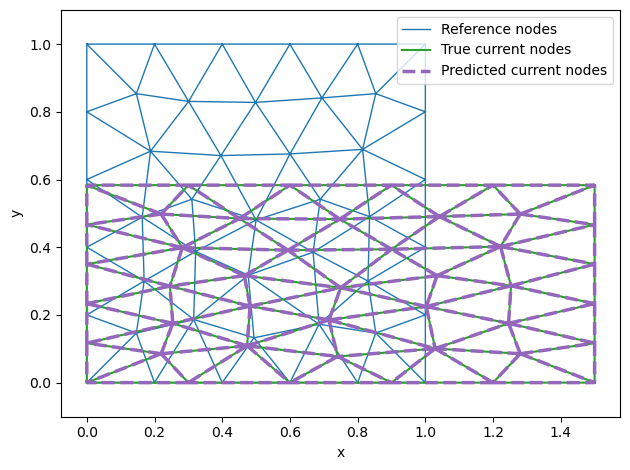

In [38]:
# Reference configuration
plt.triplot(
    ref_node_coords[:, 0],
    ref_node_coords[:, 1],
    triangles=S.S[2],
    linewidth=1.0,
    label="Reference nodes"
)

# True current configuration
plt.triplot(
    true_curr_node_coords[:, 0],
    true_curr_node_coords[:, 1],
    triangles=S.S[2],
    linewidth=1.5,
    label="True current nodes"
)

# Predicted current configuration (highlighted)
plt.triplot(
    curr_node_coords[:, 0],
    curr_node_coords[:, 1],
    triangles=S.S[2],
    linewidth=2.5,
    label="Predicted current nodes",
    linestyle="--",
)

# Axis labels and formatting
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.tight_layout()

plt.show()

## Non-variational formulation